# DATA LOADING

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results = pd.read_csv('../data/raw/results.csv')
status = pd.read_csv('../data/raw/status.csv')
races = pd.read_csv('../data/raw/races.csv')
drivers = pd.read_csv('../data/raw/drivers.csv')
constructors = pd.read_csv('../data/raw/constructors.csv')
qualifying = pd.read_csv('../data/raw/qualifying.csv')
circuits = pd.read_csv('../data/raw/circuits.csv')
driver_standings = pd.read_csv('../data/raw/driver_standings.csv')
constructor_standings = pd.read_csv('../data/raw/constructor_standings.csv')

print("results:", results.shape)
print("status:", status.shape)
print("races:", races.shape)
print("drivers:", drivers.shape)
print("constructors:", constructors.shape)
print("qualifying:", qualifying.shape)
print("circuits:", circuits.shape)
print("driver_standings:", driver_standings.shape)
print("constructor_standings:", constructor_standings.shape)

results: (26759, 18)
status: (139, 2)
races: (1125, 18)
drivers: (861, 9)
constructors: (212, 5)
qualifying: (10494, 9)
circuits: (77, 9)
driver_standings: (34863, 7)
constructor_standings: (13391, 7)


# FEATURE SELECTION

In [3]:

df = pd.read_csv('../data/processed/f1_cleaned.csv')
print(df.shape)
print(df.columns)

(4611, 50)
Index(['resultId', 'raceId', 'driverId', 'constructorId', 'grid', 'position',
       'positionOrder', 'points', 'laps', 'statusId', 'fastestLap', 'rank',
       'fastestLapTime', 'fastestLapSpeed', 'circuitId', 'race_name', 'year',
       'round', 'date', 'circuitRef', 'country', 'lat', 'lng', 'driverRef',
       'driver_forename', 'driver_surname', 'driver_nationality', 'dob',
       'constructorRef', 'constructor_name', 'constructor_nationality',
       'driver_number', 'qualifying_position', 'status',
       'driver_championship_points', 'driver_championship_position',
       'driver_wins', 'constructor_championship_points',
       'constructor_championship_position', 'constructor_wins', 'DNF',
       'driver_experience', 'constructor_dnf_rate',
       'constructor_dnf_rate_last10', 'constructor_dnf_rate_last5',
       'driver_dnf_rate', 'driver_dnf_rate_last10', 'driver_dnf_rate_last5',
       'circuit_dnf_rate', 'is_street_circuit'],
      dtype='str')


### **driver avg position**

In [4]:
df = df.sort_values(['driverId', 'date'])

df['driver_avg_position'] = df.groupby('driverId')['positionOrder'].transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
df['driver_avg_position'] = df['driver_avg_position'].fillna(10)

print(df[['driverId', 'date', 'positionOrder', 'driver_avg_position']].head(20))
print(df['driver_avg_position'].isnull().sum())
print(df['driver_avg_position'].mean())

    driverId        date  positionOrder  driver_avg_position
0          1  2014-03-16             19            10.000000
1          1  2014-03-30              1            19.000000
2          1  2014-04-06              1            10.000000
3          1  2014-04-20              1             7.000000
4          1  2014-05-11              1             5.500000
5          1  2014-05-25              2             4.600000
6          1  2014-06-08             17             4.166667
7          1  2014-06-22              2             6.000000
8          1  2014-07-06              1             5.500000
9          1  2014-07-20              3             5.000000
10         1  2014-07-27              3             4.800000
11         1  2014-08-24             19             3.200000
12         1  2014-09-07              1             5.000000
13         1  2014-09-21              1             5.000000
14         1  2014-10-05              1             5.000000
15         1  2014-10-12

### **constructor avg position**

In [5]:
df = df.sort_values(['constructorId', 'date'])

df['constructor_avg_position'] = df.groupby('constructorId')['positionOrder'].transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
df['constructor_avg_position'] = df['constructor_avg_position'].fillna(10)

print(df[['constructorId', 'date', 'positionOrder', 'constructor_avg_position']].head(20))
print(df['constructor_avg_position'].isnull().sum())
print(df['constructor_avg_position'].mean())

      constructorId        date  positionOrder  constructor_avg_position
749               1  2014-03-16              3                 10.000000
2098              1  2014-03-16              2                  3.000000
750               1  2014-03-30              6                  2.500000
2099              1  2014-03-30              9                  3.666667
751               1  2014-04-06             17                  5.000000
2100              1  2014-04-06             18                  7.400000
752               1  2014-04-20             11                  9.166667
2101              1  2014-04-20             13                  9.428571
753               1  2014-05-11             11                  9.875000
2102              1  2014-05-11             12                 10.000000
754               1  2014-05-25              6                 10.200000
2103              1  2014-05-25             10                 10.500000
755               1  2014-06-08              4     

### **grip penalty**

In [6]:
df['grid_penalty'] = df['grid'] - df['qualifying_position']

print(df[['grid', 'qualifying_position', 'grid_penalty']].loc[df['grid_penalty'] != 0].head(20))
print(df['grid_penalty'].isnull().sum())

      grid  qualifying_position  grid_penalty
749     10                 11.0          -1.0
751      6                  7.0          -1.0
2100     8                  9.0          -1.0
2102    14                 15.0          -1.0
756     11                 12.0          -1.0
2108    21                 10.0          11.0
2113    11                  6.0           5.0
765     12                  7.0           5.0
2114     7                  8.0          -1.0
768     16                 17.0          -1.0
309     13                 15.0          -2.0
773     10                 12.0          -2.0
310     13                 14.0          -1.0
311     19                 15.0           4.0
775     20                 17.0           3.0
314     20                 18.0           2.0
778     19                 17.0           2.0
315     16                 17.0          -1.0
779     15                 16.0          -1.0
317     12                 14.0          -2.0
0


In [7]:
def time_to_seconds(time_str):
    if pd.isna(time_str) or time_str == '\\N':
        return np.nan
    try:
        parts = str(time_str).split(':')
        minutes = float(parts[0])
        seconds = float(parts[1])
        return minutes * 60 + seconds
    except:
        return np.nan

# apply to q1, q2, q3
qualifying['q1_seconds'] = qualifying['q1'].apply(time_to_seconds)
qualifying['q2_seconds'] = qualifying['q2'].apply(time_to_seconds)
qualifying['q3_seconds'] = qualifying['q3'].apply(time_to_seconds)

print(qualifying[['q1', 'q1_seconds']].head())

         q1  q1_seconds
0  1:26.572      86.572
1  1:26.103      86.103
2  1:25.664      85.664
3  1:25.994      85.994
4  1:25.960      85.960


In [8]:
qualifying['best_qualifying_time'] = qualifying[['q1_seconds', 'q2_seconds', 'q3_seconds']].min(axis=1)

qualifying['pole_time'] = qualifying.groupby('raceId')['q3_seconds'].transform('min')

qualifying['quali_gap_to_pole'] = qualifying['q3_seconds'].fillna(qualifying['best_qualifying_time']) - qualifying['pole_time']

print(qualifying[['raceId', 'driverId', 'position', 'best_qualifying_time', 'pole_time', 'quali_gap_to_pole']].loc[qualifying['position'] == 1].head(10))

     raceId  driverId  position  best_qualifying_time  pole_time  \
0        18         1         1                85.187     86.714   
22       19        13         1                94.412     95.748   
44       20         9         1                91.745     93.096   
66       21         8         1                80.701     81.813   
88       22        13         1                85.994     87.617   
108      23        13         1                75.110     75.787   
128      24         1         1                76.909     77.886   
148      25         8         1                75.133     76.449   
168      26         5         1                79.597     81.049   
188      27         1         1                74.603     75.666   

     quali_gap_to_pole  
0                  0.0  
22                 0.0  
44                 0.0  
66                 0.0  
88                 0.0  
108                0.0  
128                0.0  
148                0.0  
168                0.0  
1

In [9]:
qualifying_clean = qualifying[['raceId', 'driverId', 'quali_gap_to_pole']]

df = pd.merge(df, qualifying_clean, on=['raceId', 'driverId'], how='left')

In [10]:
print(df['quali_gap_to_pole'].isnull().sum())
print(df['quali_gap_to_pole'].describe())

87
count    4524.000000
mean        1.756380
std         2.679749
min       -17.753000
25%         0.733750
50%         1.530500
75%         2.418000
max        40.245000
Name: quali_gap_to_pole, dtype: float64


In [11]:
print(qualifying[qualifying['raceId']==18][['driverId', 'position', 'q1_seconds', 'q2_seconds', 'q3_seconds', 'best_qualifying_time', 'pole_time', 'quali_gap_to_pole']].sort_values('position').head(20))

    driverId  position  q1_seconds  q2_seconds  q3_seconds  \
0          1         1      86.572      85.187      86.714   
1          9         2      86.103      85.315      86.869   
2          5         3      85.664      85.452      87.079   
3         13         4      85.994      85.691      87.178   
4          2         5      85.960      85.518      87.236   
5         15         6      86.427      86.101      88.527   
6          3         7      86.295      86.059      88.687   
7         14         8      86.381      86.063      89.041   
8         10         9      86.919      86.164      89.593   
9         20        10      86.702      85.842         NaN   
10        22        11      86.369      86.173         NaN   
11         4        12      86.907      86.188         NaN   
12        18        13      86.712      86.259         NaN   
13         6        14      86.891      86.413         NaN   
14        17        15      86.914         NaN         NaN   
15      

In [12]:
print(df['quali_gap_to_pole'].corr(df['positionOrder']))

0.2595500324479991


In [13]:
print(df['qualifying_position'].corr(df['positionOrder']))

0.6329097197488928


In [14]:
df = df.drop(columns=['quali_gap_to_pole'], errors='ignore')

In [15]:
import joblib


xgb_dnf = joblib.load('../models/dnf_model.pkl')


dnf_features = ['grid',
 'qualifying_position',
 'driver_championship_points',
 'driver_championship_position',
 'driver_wins',
 'constructor_championship_points',
 'constructor_championship_position',
 'constructor_wins',
 'year',
 'round',
 'driver_experience',
 'constructor_dnf_rate',
 'constructor_dnf_rate_last10',
 'constructor_dnf_rate_last5',
 'driver_dnf_rate',
 'driver_dnf_rate_last10',
 'driver_dnf_rate_last5',
 'circuit_dnf_rate',
 'is_street_circuit']

df['dnf_probability'] = xgb_dnf.predict_proba(df[dnf_features])[:, 1]

print(df['dnf_probability'].describe())

count    4611.000000
mean        0.519189
std         0.113963
min         0.144650
25%         0.463206
50%         0.540955
75%         0.594655
max         0.836697
Name: dnf_probability, dtype: float64


In [16]:
print(df['dnf_probability'].corr(df['positionOrder']))

0.6507978781454099


In [17]:
print(df.columns.tolist())

['resultId', 'raceId', 'driverId', 'constructorId', 'grid', 'position', 'positionOrder', 'points', 'laps', 'statusId', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'circuitId', 'race_name', 'year', 'round', 'date', 'circuitRef', 'country', 'lat', 'lng', 'driverRef', 'driver_forename', 'driver_surname', 'driver_nationality', 'dob', 'constructorRef', 'constructor_name', 'constructor_nationality', 'driver_number', 'qualifying_position', 'status', 'driver_championship_points', 'driver_championship_position', 'driver_wins', 'constructor_championship_points', 'constructor_championship_position', 'constructor_wins', 'DNF', 'driver_experience', 'constructor_dnf_rate', 'constructor_dnf_rate_last10', 'constructor_dnf_rate_last5', 'driver_dnf_rate', 'driver_dnf_rate_last10', 'driver_dnf_rate_last5', 'circuit_dnf_rate', 'is_street_circuit', 'driver_avg_position', 'constructor_avg_position', 'grid_penalty', 'dnf_probability']


In [18]:
stage2_features = [
    'grid',
    'qualifying_position',
    'grid_penalty',
    'driver_championship_position',
    'driver_championship_points',
    'driver_wins',
    'constructor_championship_position',
    'constructor_championship_points',
    'constructor_wins',
    'driver_experience',
    'driver_avg_position',
    'constructor_avg_position',
    'year',
    'round',
    'is_street_circuit',
    'dnf_probability'
]

X = df[stage2_features]
y = df['positionOrder']

print(X.shape)
print(X.isnull().sum())

(4611, 16)
grid                                 0
qualifying_position                  0
grid_penalty                         0
driver_championship_position         0
driver_championship_points           0
driver_wins                          0
constructor_championship_position    0
constructor_championship_points      0
constructor_wins                     0
driver_experience                    0
driver_avg_position                  0
constructor_avg_position             0
year                                 0
round                                0
is_street_circuit                    0
dnf_probability                      0
dtype: int64


# TRAIN

In [19]:
train = df[df['year'] < 2022]
test = df[df['year'] >= 2022]

X_train = train[stage2_features]
y_train = train['positionOrder']

X_test = test[stage2_features]
y_test = test['positionOrder']

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Train position range:", y_train.min(), "-", y_train.max())
print("Test position range:", y_test.min(), "-", y_test.max())

Train: (3257, 16)
Test: (1354, 16)
Train position range: 1 - 22
Test position range: 1 - 20


In [20]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error

baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print(f"Baseline MAE: {mean_absolute_error(y_test, baseline_pred):.2f}")

Baseline MAE: 4.98


In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(f"Baseline MAE: {mean_absolute_error(y_test, baseline_pred):.2f}")
print(f"Random Forest MAE: {mean_absolute_error(y_test, rf_pred):.2f}")

Baseline MAE: 4.98
Random Forest MAE: 3.02


In [22]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=2, subsample=0.8, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print(f"Baseline MAE: {mean_absolute_error(y_test, baseline_pred):.2f}")
print(f"XGBoost MAE: {mean_absolute_error(y_test, xgb_pred):.2f}")

Baseline MAE: 4.98
XGBoost MAE: 2.89


In [23]:
from sklearn.model_selection import RandomizedSearchCV

In [24]:


param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_reg = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=1,
    random_state=42
)

xgb_reg.fit(X_train, y_train)
print("Best Hyperparameters:", xgb_reg.best_params_)
best_xgb = xgb_reg.best_estimator_
best_xgb_pred = best_xgb.predict(X_test)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Hyperparameters: {'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [25]:
print(f"Best XGBoost MAE: {mean_absolute_error(y_test, best_xgb_pred):.2f}")


Best XGBoost MAE: 2.92


driver_championship_position         0.371196
dnf_probability                      0.211727
constructor_championship_position    0.095052
qualifying_position                  0.063554
driver_championship_points           0.045096
grid                                 0.030727
constructor_championship_points      0.026216
constructor_wins                     0.023835
driver_avg_position                  0.020587
grid_penalty                         0.019508
constructor_avg_position             0.019252
year                                 0.018280
driver_wins                          0.016682
driver_experience                    0.016661
round                                0.011813
is_street_circuit                    0.009812
dtype: float32


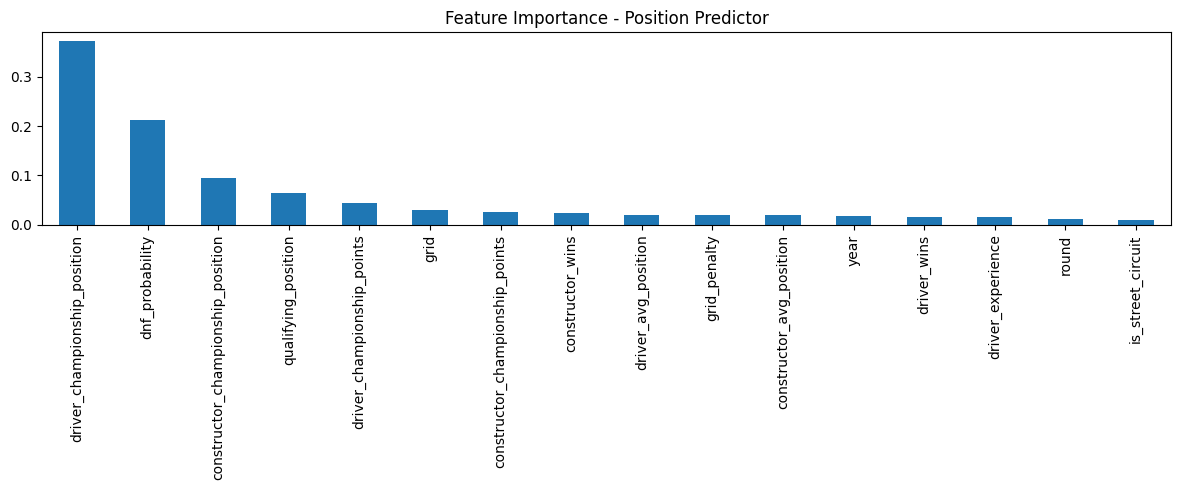

In [26]:
importance = pd.Series(
    xgb_reg.best_estimator_.feature_importances_,
    index=stage2_features
).sort_values(ascending=False)

print(importance)

importance.plot(kind='bar', figsize=(12, 5), title='Feature Importance - Position Predictor')
plt.tight_layout()
plt.show()

In [27]:

race_2023 = test[test['year'] == 2023].copy()
race_2023['predicted_position'] = xgb_reg.best_estimator_.predict(race_2023[stage2_features])


bahrain_2023 = race_2023[race_2023['race_name'] == 'Bahrain Grand Prix'].copy()
bahrain_2023 = bahrain_2023[['driver_forename', 'driver_surname', 'positionOrder', 'predicted_position']]
bahrain_2023['predicted_position'] = bahrain_2023['predicted_position'].round(0).astype(int)
bahrain_2023 = bahrain_2023.sort_values('positionOrder')
print(bahrain_2023)

     driver_forename driver_surname  positionOrder  predicted_position
2168             Max     Verstappen              1                   2
2167          Sergio          Pérez              2                   2
3002        Fernando         Alonso              3                   3
1712          Carlos          Sainz              4                   4
3455           Lewis       Hamilton              5                   6
3003           Lance         Stroll              6                   6
3456          George        Russell              7                   6
2870        Valtteri         Bottas              8                   6
4472          Pierre          Gasly              9                  10
816        Alexander          Albon             10                  11
4339            Yuki        Tsunoda             11                  11
817            Logan       Sargeant             12                  12
4050           Kevin      Magnussen             13                  13
4340  

In [28]:
print(bahrain_2023.sort_values('predicted_position').head(3))

     driver_forename driver_surname  positionOrder  predicted_position
2168             Max     Verstappen              1                   2
2167          Sergio          Pérez              2                   2
3002        Fernando         Alonso              3                   3


In [29]:
bahrain_2023['predicted_rank'] = bahrain_2023['predicted_position'].rank(method='first').astype(int)

bahrain_2023 = bahrain_2023[['driver_forename', 'driver_surname', 'positionOrder', 'predicted_rank']]
bahrain_2023 = bahrain_2023.sort_values('predicted_rank')
print(bahrain_2023)

     driver_forename driver_surname  positionOrder  predicted_rank
2168             Max     Verstappen              1               1
2167          Sergio          Pérez              2               2
3002        Fernando         Alonso              3               3
1712          Carlos          Sainz              4               4
3455           Lewis       Hamilton              5               5
3003           Lance         Stroll              6               6
3456          George        Russell              7               7
2870        Valtteri         Bottas              8               8
4472          Pierre          Gasly              9               9
816        Alexander          Albon             10              10
4339            Yuki        Tsunoda             11              11
817            Logan       Sargeant             12              12
4050           Kevin      Magnussen             13              13
4340            Nyck       de Vries             14            

**The model already outputs continuous scores. You just apply .rank() as a post-processing step after prediction. That's the right approach.**

In [30]:
# joblib.dump(xgb_reg.best_estimator_, '../models/position_model.pkl')
# print("Position model saved!")

# **PLAYGROUND**

In [31]:
race_year = test[test['year'] == 2023].copy()
race_year['predicted_position'] = xgb_reg.best_estimator_.predict(race_year[stage2_features])

race_name = 'Abu Dhabi Grand Prix'

race_results = race_year[race_year['race_name'] == race_name].copy()
race_results = race_results[['driver_forename', 'driver_surname', 'positionOrder', 'predicted_position']]
race_results['predicted_position'] = race_results['predicted_position'].rank(method='first').astype(int)
race_results = race_results.sort_values('positionOrder')
print(race_results)

     driver_forename driver_surname  positionOrder  predicted_position
2210             Max     Verstappen              1                   1
1755         Charles        Leclerc              2                   6
3498          George        Russell              3                   4
2209          Sergio          Pérez              4                   2
404            Lando         Norris              5                   8
405            Oscar        Piastri              6                   3
3042        Fernando         Alonso              7                   7
4382            Yuki        Tsunoda              8                  12
3497           Lewis       Hamilton              9                   5
3043           Lance         Stroll             10                  10
4381          Daniel      Ricciardo             11                  15
4513         Esteban           Ocon             12                  11
4514          Pierre          Gasly             13                  13
858   

In [32]:
abs_error = abs(
    race_results.positionOrder -
    race_results.predicted_position
)

print(abs_error.mean())

2.3


In [33]:
abs_error.describe()

count    20.000000
mean      2.300000
std       2.178846
min       0.000000
25%       1.000000
50%       2.000000
75%       4.000000
max       9.000000
dtype: float64

In [36]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 4611 entries, 0 to 4610
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   grid                               4611 non-null   int64  
 1   qualifying_position                4611 non-null   float64
 2   grid_penalty                       4611 non-null   float64
 3   driver_championship_position       4611 non-null   float64
 4   driver_championship_points         4611 non-null   float64
 5   driver_wins                        4611 non-null   float64
 6   constructor_championship_position  4611 non-null   float64
 7   constructor_championship_points    4611 non-null   float64
 8   constructor_wins                   4611 non-null   float64
 9   driver_experience                  4611 non-null   int64  
 10  driver_avg_position                4611 non-null   float64
 11  constructor_avg_position           4611 non-null   float64
 12  yea